# Traitement des données

Dans ce notebook, nous mettons en place plusieurs étapes de préparation et d’analyse des données avant la modélisation :

1. **Chargement des données :**  
   - Importer le fichier CSV contenant l’ensemble des variables (climatiques, économiques, etc.).
   - Convertir la colonne Date au format datetime et trier les observations.

2. **Analyse des valeurs manquantes :**  
   - Identifier la proportion de NaN par colonne.
   - Décider de la stratégie de traitement (suppression ou imputation si necessaire).

3. **Visualisation des distributions :**  
   - Examiner la répartition des variables clés (histogrammes, boxplots) pour détecter d’éventuelles anomalies ou asymétries importantes.

4. **Normalisation des variables numériques :**  
   - Appliquer la méthode StandardScaler sur les variables pertinentes pour les ramener à une moyenne de 0 et un écart type de 1.

5. **Sélection de la période d’étude (Panel) :**  
   - Ne conserver que la fenêtre temporelle souhaitée (2003-01 à 2023-12).
   - Vérifier la cohérence des données pour chaque mine (13 mines au total).

6. **Statistiques descriptives :**  
   - Calculer les mesures de tendance centrale et de dispersion (moyenne, médiane, écart type, etc.).
   - Fournir un aperçu global du comportement des variables.

7. **Corrélation :**  
   - Étudier les relations linéaires entre variables clés (matrice de corrélation, heatmap).
   - Identifier d’éventuelles multicolinéarités et variables redondantes.

Ce pipeline garantit une **qualité** et une **cohérence** optimales pour nos analyses et nos futurs modèles prédictifs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## 1. Chargement des données

In [2]:
# Adaptez le chemin vers votre fichier CSV
df = pd.read_csv(r"C:\Users\march\OneDrive\Bureau\Data_Science\Dossier\02.CleanData\final_merged_data1.csv", sep=";")

print("Aperçu des données :")
print(df.head())

# Convertir la colonne Date en datetime
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')  # Adapter le format si nécessaire
df = df.sort_values('Date')

# Afficher la liste des colonnes disponibles
print("\nListe des colonnes :")
print(df.columns.tolist())


Aperçu des données :
      Date    Mine  Production   Latitude  Longitude  Cloud_Cover  \
0  2003-01  Andina   19.799999 -33.150873 -70.261021    24.800001   
1  2003-02  Andina   18.900000 -33.150873 -70.261021    18.100000   
2  2003-03  Andina   20.299999 -33.150873 -70.261021    26.000000   
3  2003-04  Andina   18.299999 -33.150873 -70.261021    37.799999   
4  2003-05  Andina   20.000000 -33.150873 -70.261021    40.400002   

   Diurnal_Temp_Range    Frost_Days  Potential_Evapotranspiration  \
0           11.200000  6.177600e+14                           4.4   
1           12.400001  9.011519e+14                           4.3   
2           10.100000  7.801920e+14                           3.4   
3            8.100000  1.320192e+15                           2.3   
4            7.300000  1.963872e+15                           1.5   

   Cloud_Cover_historique  ...  Wet_Days_historique  Anomalie_Wet_Days  \
0               31.300001  ...         7.103635e+14       1.968036e+15   
1

In [3]:
df.rename(columns={
    "Refined Copper Values (1)": "refined_copp",
    "Blister Copper Values (2)": "blister_copp",
    "Bulk Copper Values (3)": "bulk_copp",
    "Totals": "export_tot"
}, inplace=True)

# Vérifions la liste des colonnes pour adapter les variables
print("\nColonnes disponibles :")
print(df.columns.tolist())


Colonnes disponibles :
['Date', 'Mine', 'Production', 'Latitude', 'Longitude', 'Cloud_Cover', 'Diurnal_Temp_Range', 'Frost_Days', 'Potential_Evapotranspiration', 'Cloud_Cover_historique', 'Anomalie_Cloud_Cover', 'Diurnal_Temp_Range_historique', 'Anomalie_Diurnal_Temp_Range', 'Frost_Days_historique', 'Anomalie_Frost_Days', 'Potential_Evapotranspiration_historique', 'Anomalie_Potential_Evapotranspiration', 'Precipitation', 'Temperature', 'Precipitation_historique', 'Anomalie_Precipitation', 'Temperature_historique', 'Anomalie_Temperature', 'Temp_Min', 'Temp_Max', 'Vapor_Pressure', 'Wet_Days', 'Temp_Min_historique', 'Anomalie_Temp_Min', 'Temp_Max_historique', 'Anomalie_Temp_Max', 'Vapor_Pressure_historique', 'Anomalie_Vapor_Pressure', 'Wet_Days_historique', 'Anomalie_Wet_Days', 'prix_lme', 'prix_comex', 'taux_variation_lme', 'taux_variation_comex', 'refined_copp', 'blister_copp', 'bulk_copp', 'export_tot']


## 2. Analyse des valeurs manquantes

In [4]:
print("\nSomme des valeurs manquantes par colonne :")
print(df.isnull().sum())



Somme des valeurs manquantes par colonne :
Date                                       0
Mine                                       0
Production                                 0
Latitude                                   0
Longitude                                  0
Cloud_Cover                                0
Diurnal_Temp_Range                         0
Frost_Days                                 0
Potential_Evapotranspiration               0
Cloud_Cover_historique                     0
Anomalie_Cloud_Cover                       0
Diurnal_Temp_Range_historique              0
Anomalie_Diurnal_Temp_Range                0
Frost_Days_historique                      0
Anomalie_Frost_Days                        0
Potential_Evapotranspiration_historique    0
Anomalie_Potential_Evapotranspiration      0
Precipitation                              0
Temperature                                0
Precipitation_historique                   0
Anomalie_Precipitation                     0
Temperature

## 3. Visualisation des distributions

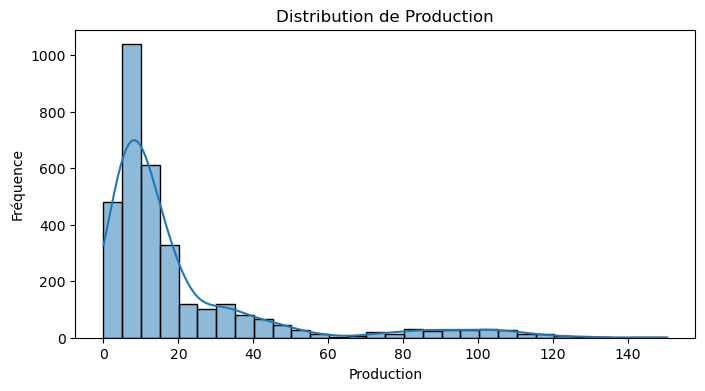

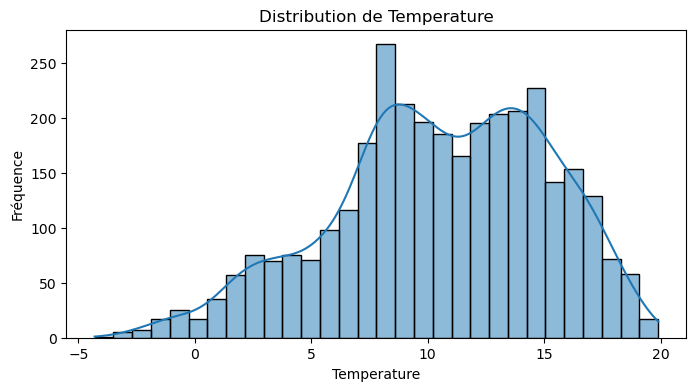

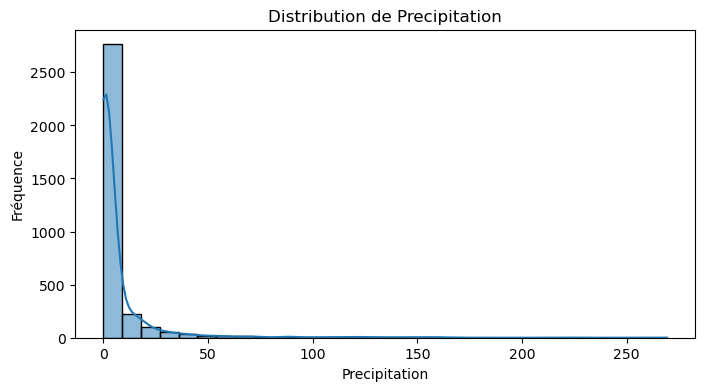

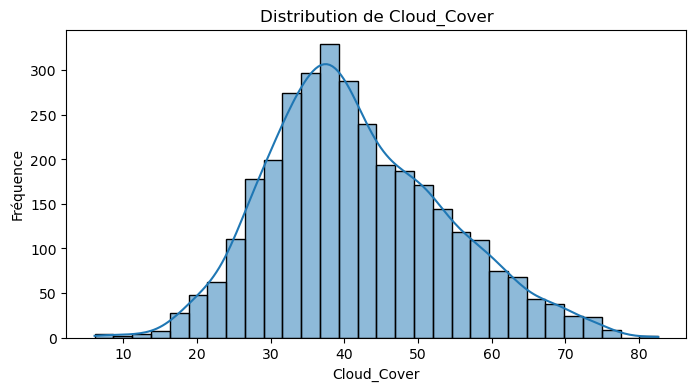

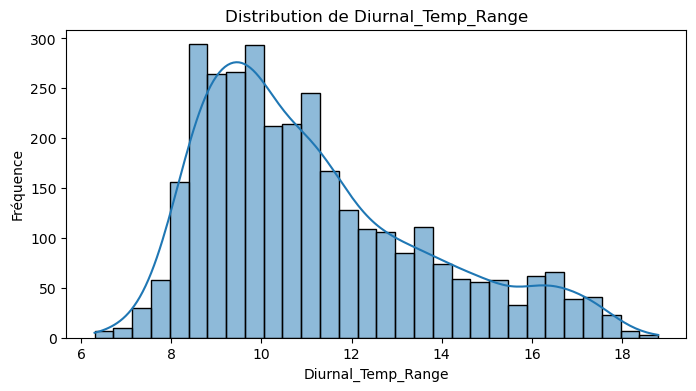

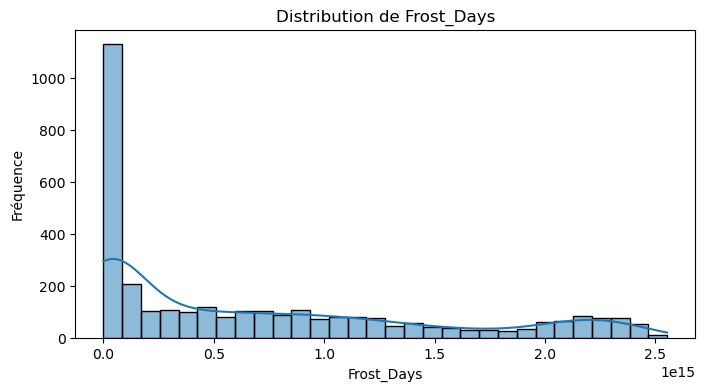

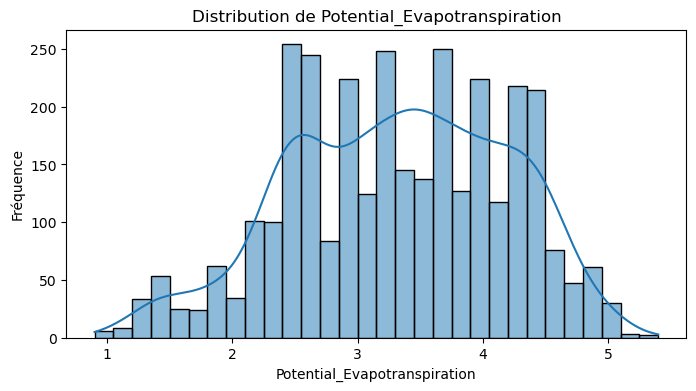

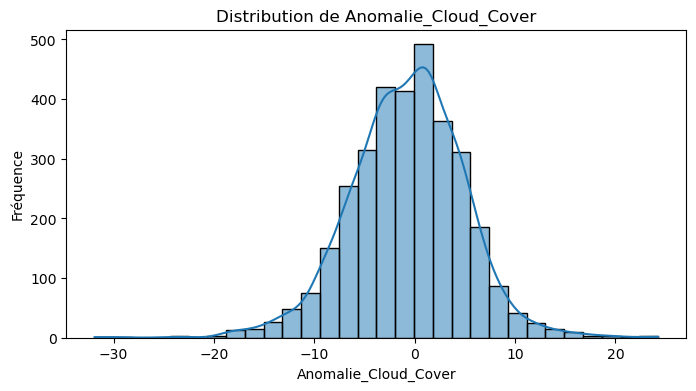

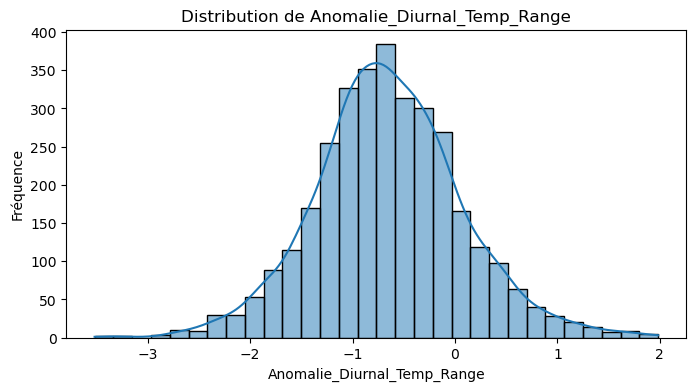

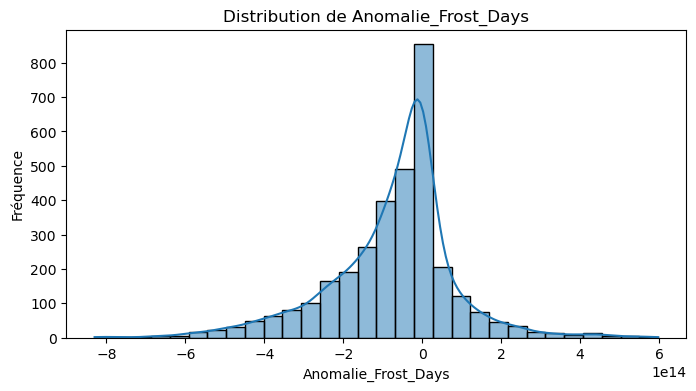

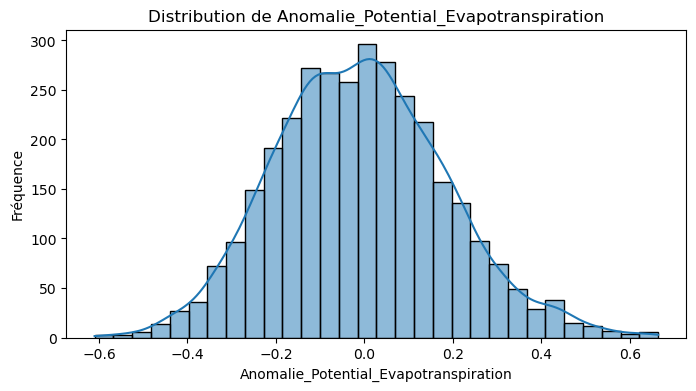

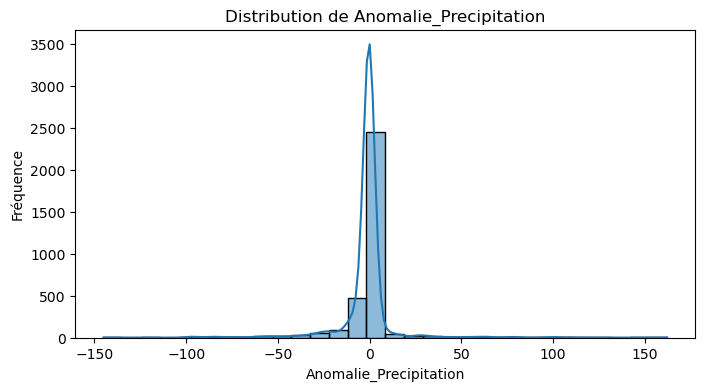

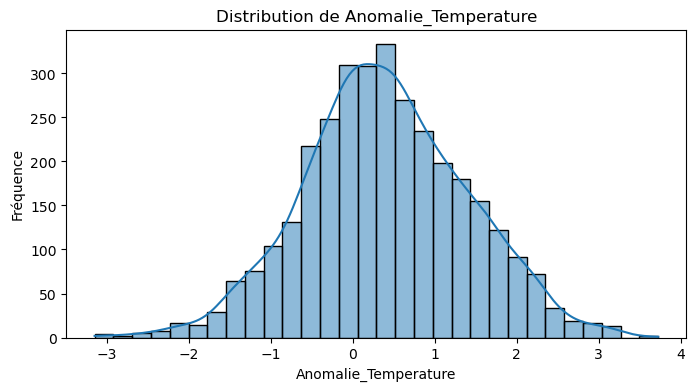

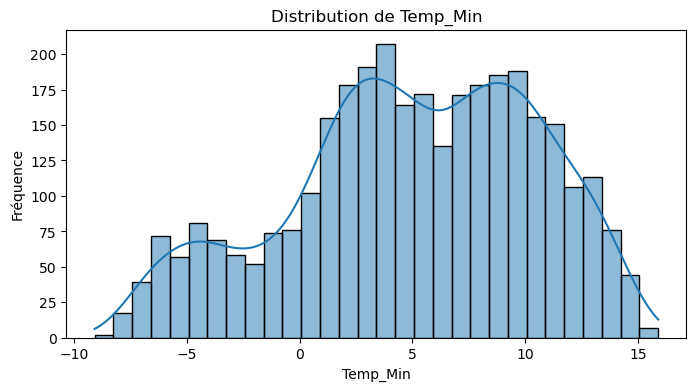

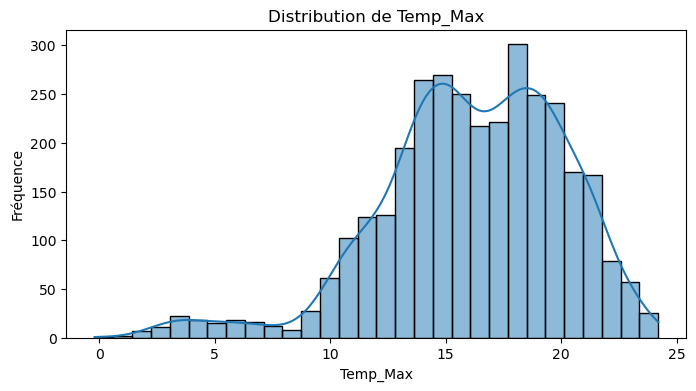

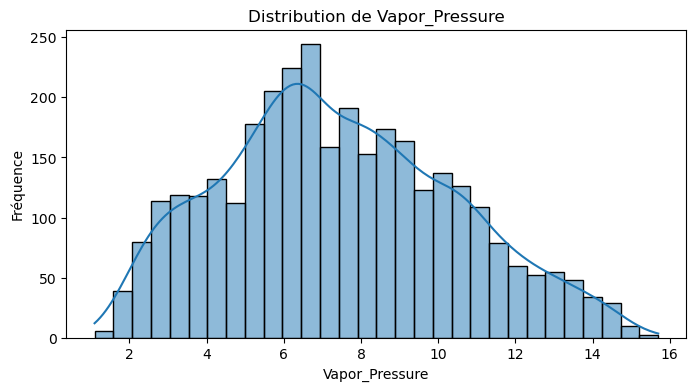

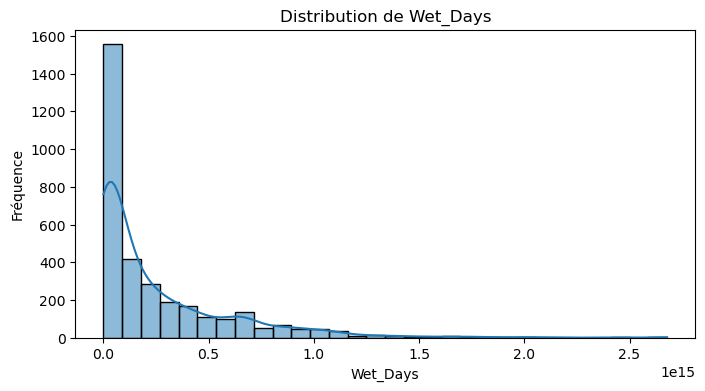

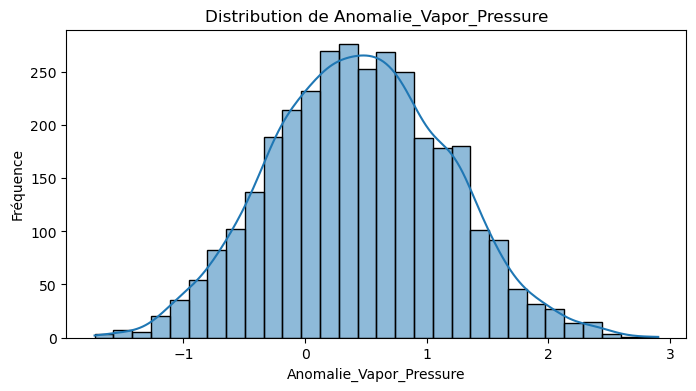

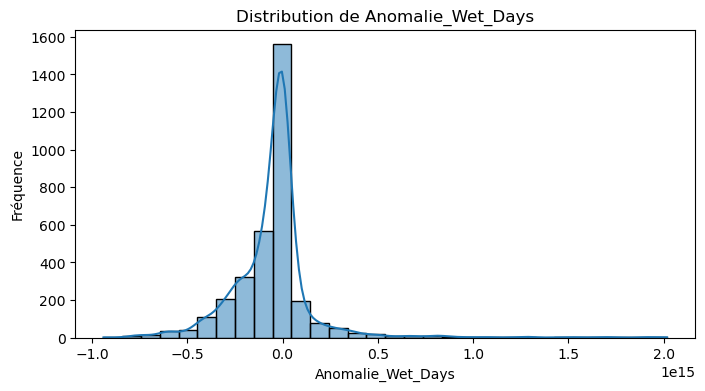

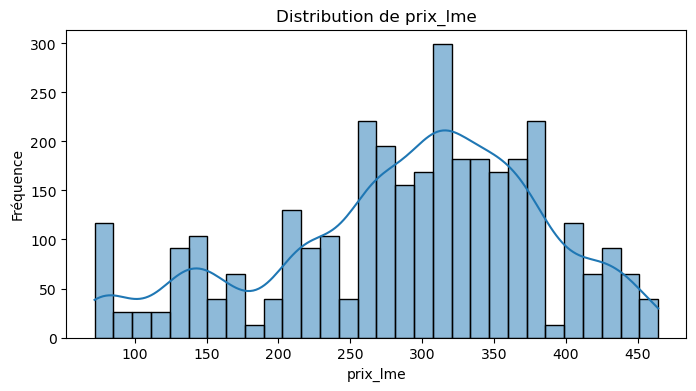

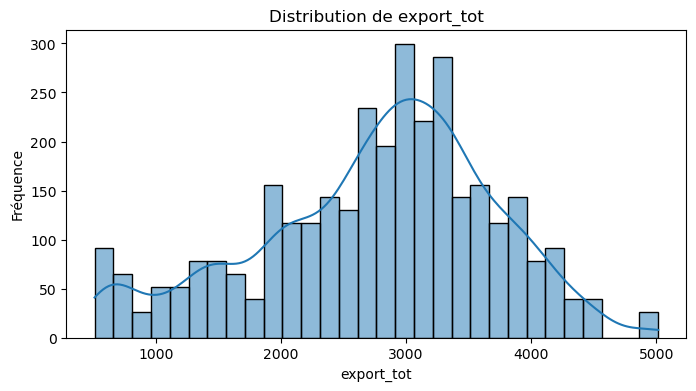

In [5]:
# Sélection de quelques variables clés pour la modélisation
key_vars = ['Production', 'Temperature', 'Precipitation', 'Cloud_Cover', 'Diurnal_Temp_Range', 
            'Frost_Days', 'Potential_Evapotranspiration', 'Anomalie_Cloud_Cover',
            'Anomalie_Diurnal_Temp_Range',  'Anomalie_Frost_Days', 
            'Anomalie_Potential_Evapotranspiration', 'Anomalie_Precipitation', 'Anomalie_Temperature',
            'Temp_Min', 'Temp_Max', 'Vapor_Pressure', 'Wet_Days', 'Anomalie_Vapor_Pressure',
            'Anomalie_Wet_Days', 'prix_lme', 'export_tot'
           ]

for var in key_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[var].dropna(), kde=True, bins=30)
    plt.title(f"Distribution de {var}")
    plt.xlabel(var)
    plt.ylabel("Fréquence")
    plt.show()

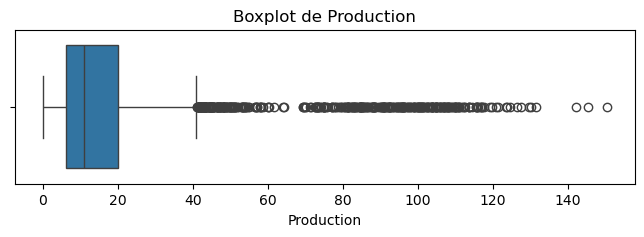

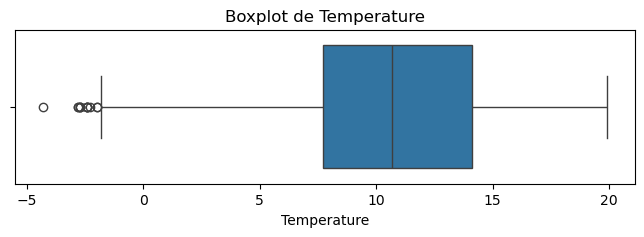

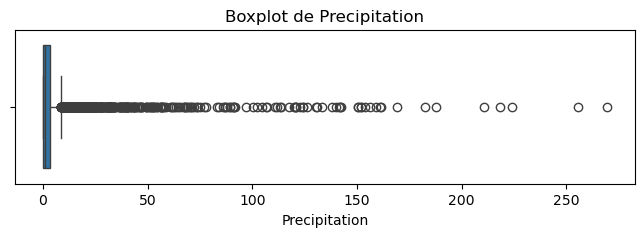

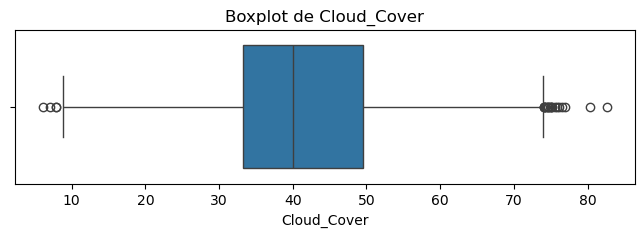

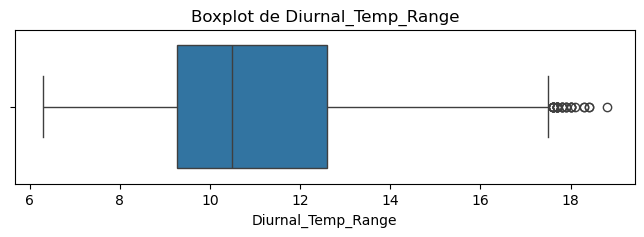

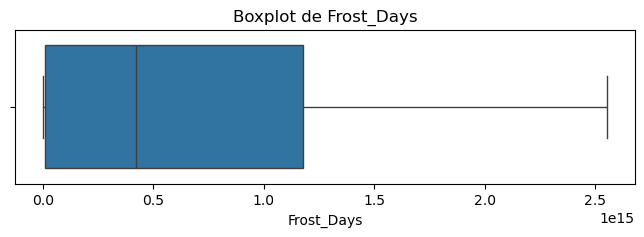

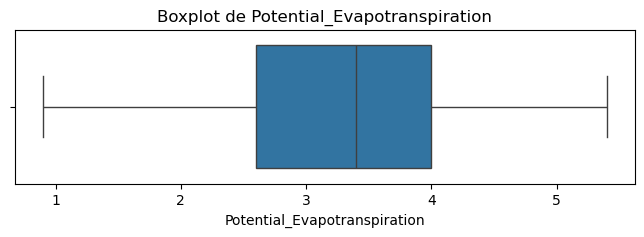

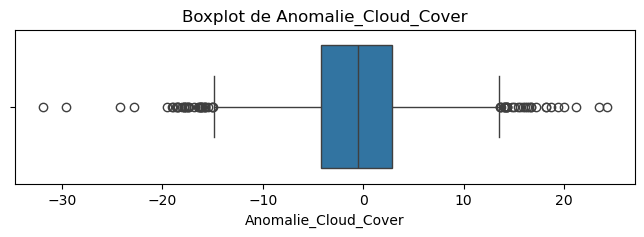

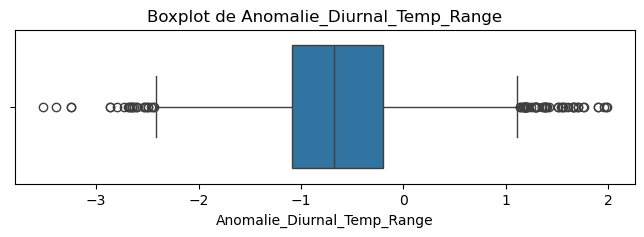

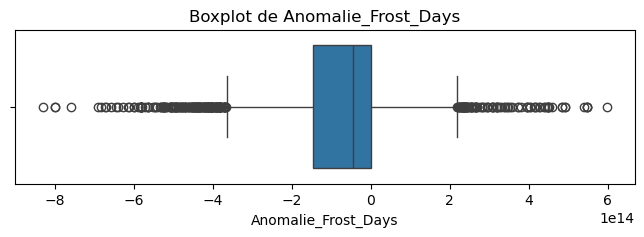

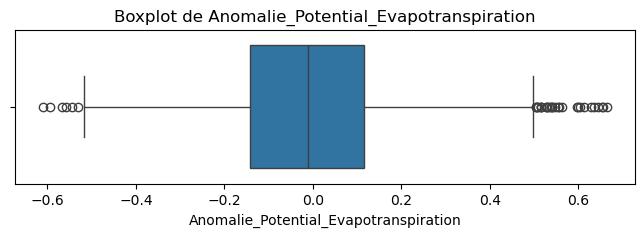

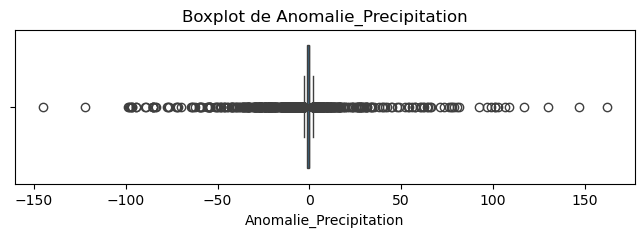

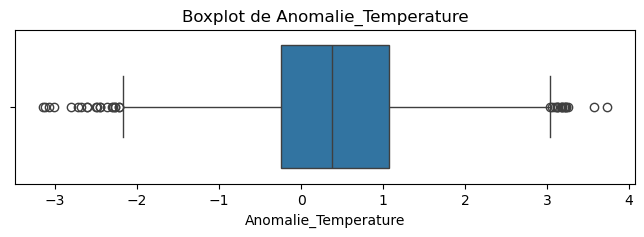

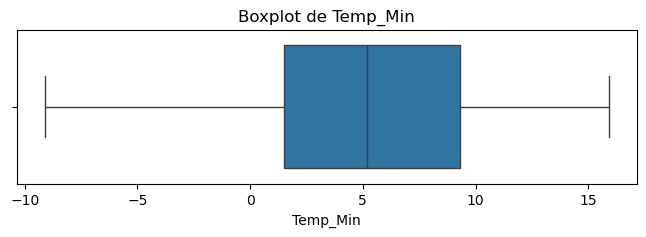

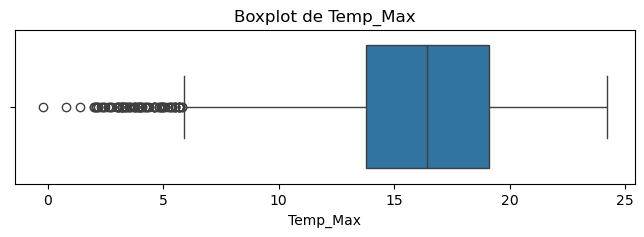

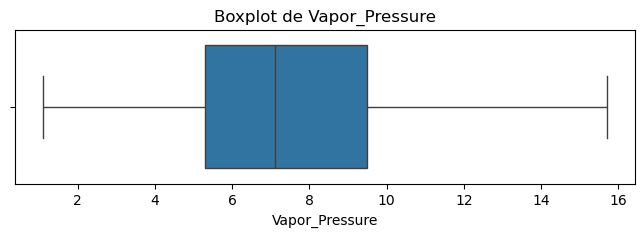

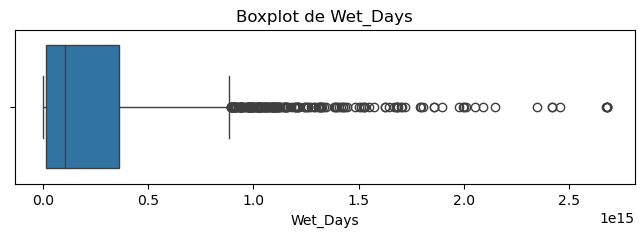

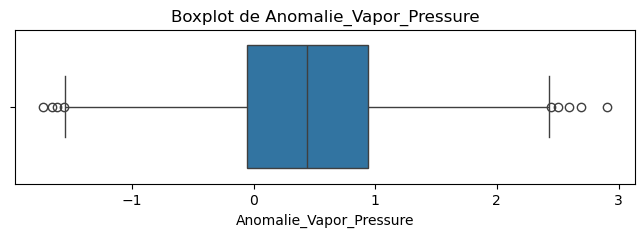

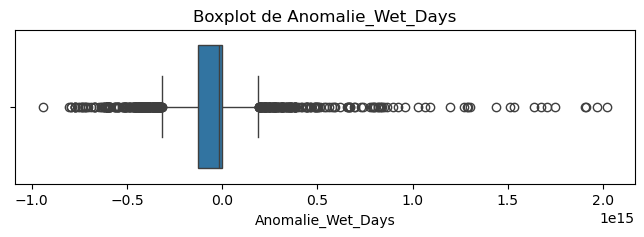

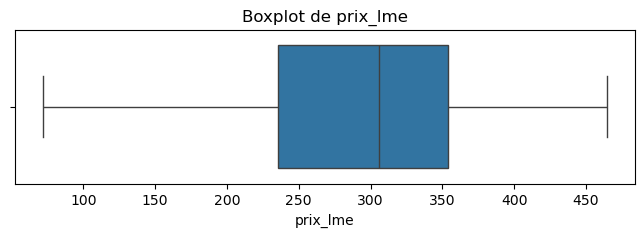

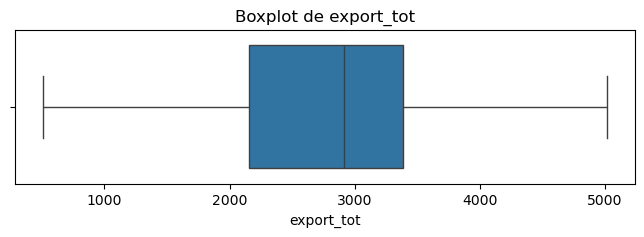

In [6]:
# Vous pouvez aussi visualiser les boxplots pour détecter d'éventuels outliers
for var in key_vars:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df[var].dropna())
    plt.title(f"Boxplot de {var}")
    plt.show()

## 4. Normalisation des variables numériques

In [7]:
# Nous utiliserons StandardScaler pour normaliser les variables clés.
scaler = StandardScaler()

# Copier le DataFrame pour y ajouter les versions normalisées
df_norm = df.copy()

for var in key_vars:
    # On crée une nouvelle colonne nommée par exemple "Production_norm"
    df_norm[var + "_norm"] = scaler.fit_transform(df[[var]])

print("\nAperçu des variables normalisées :")
print(df_norm[[var + "_norm" for var in key_vars]].head())


Aperçu des variables normalisées :
      Production_norm  Temperature_norm  Precipitation_norm  Cloud_Cover_norm  \
0           -0.002952         -0.159135            5.272401         -1.406906   
2520        -0.574271          1.684008           -0.263909          0.512154   
756          0.645353         -0.571132            0.142880          2.748276   
2268        -0.549960         -0.462712            0.415727          2.748276   
1008        -0.096146         -0.137451            0.435571          2.506308   

      Diurnal_Temp_Range_norm  Frost_Days_norm  \
0                    0.023458        -0.108563   
2520                -1.180447        -0.907964   
756                 -0.417974         0.240266   
2268                -0.538364         0.074796   
1008                -0.698885        -0.345588   

      Potential_Evapotranspiration_norm  Anomalie_Cloud_Cover_norm  \
0                              1.248842                  -1.025593   
2520                           1.248

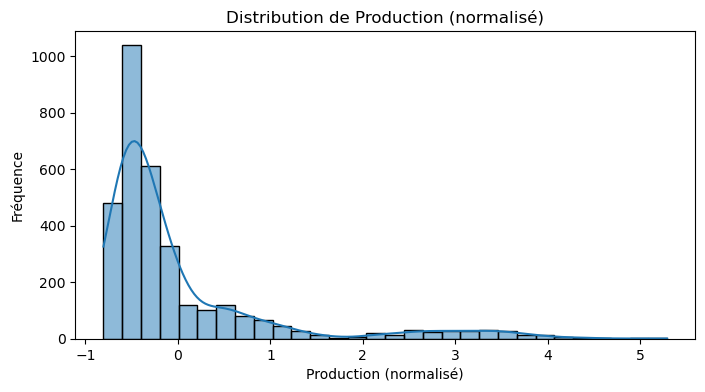

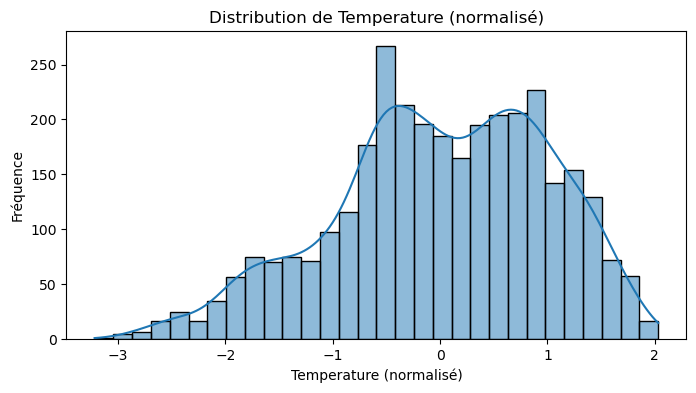

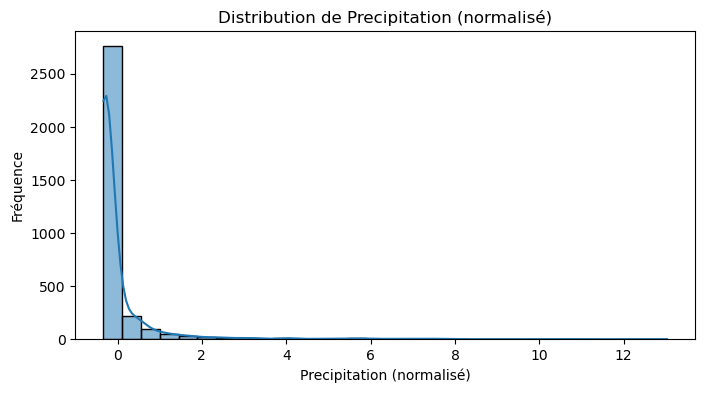

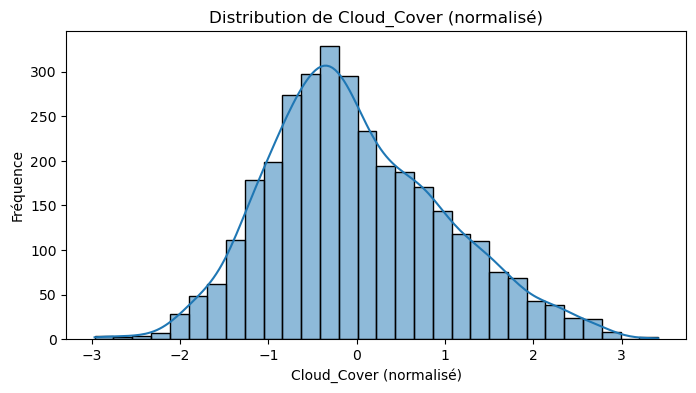

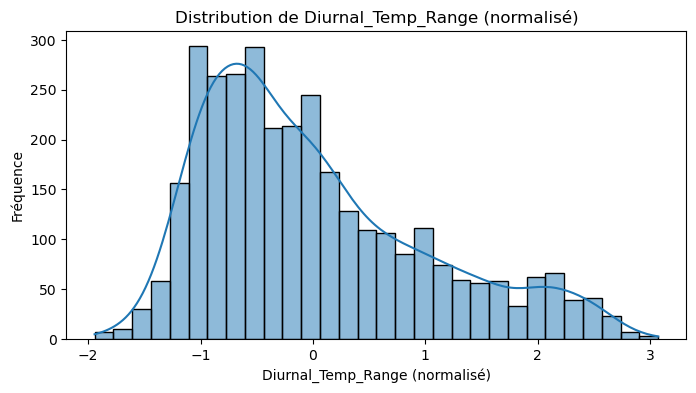

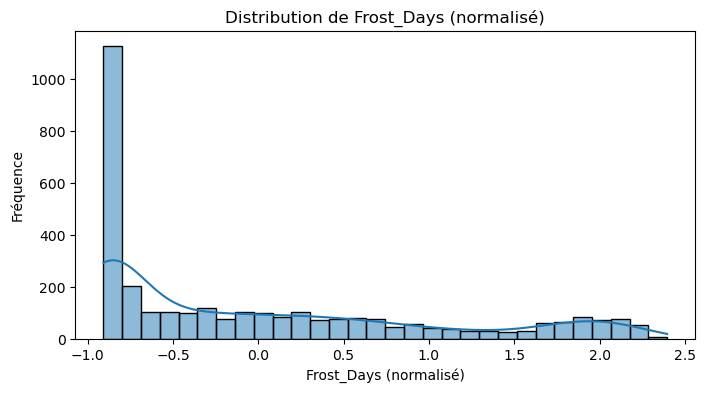

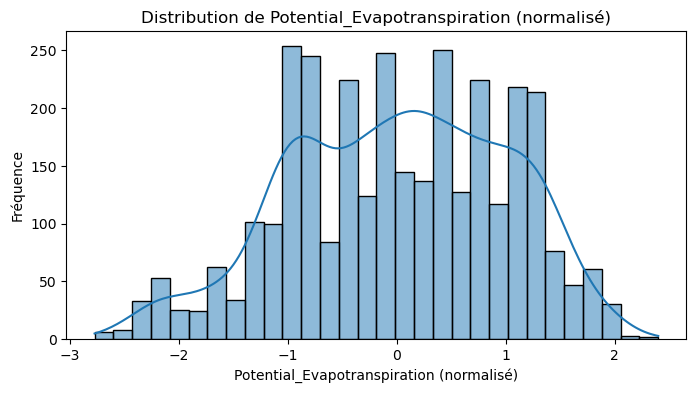

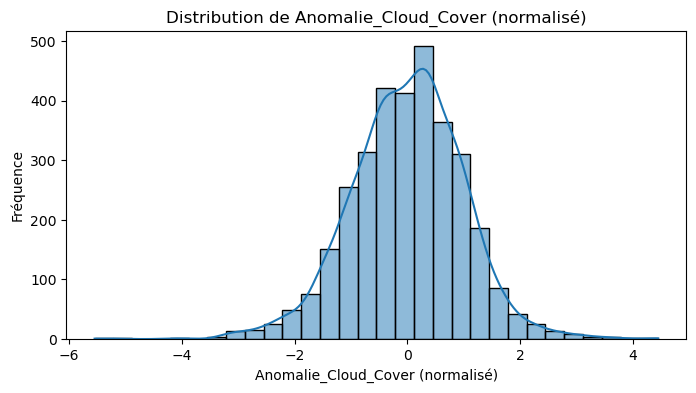

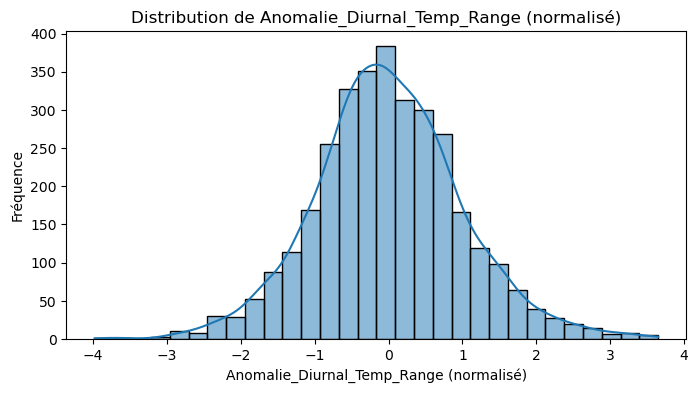

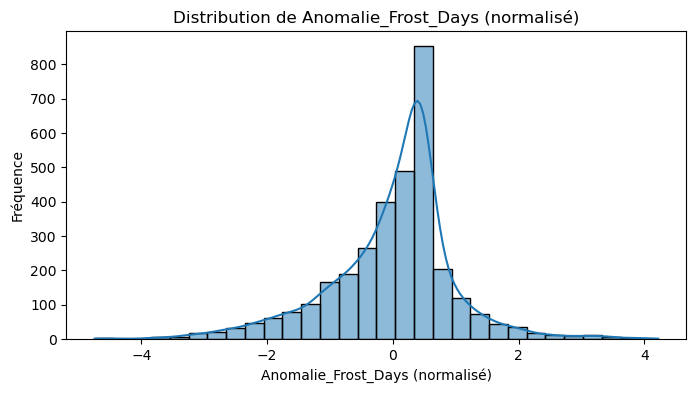

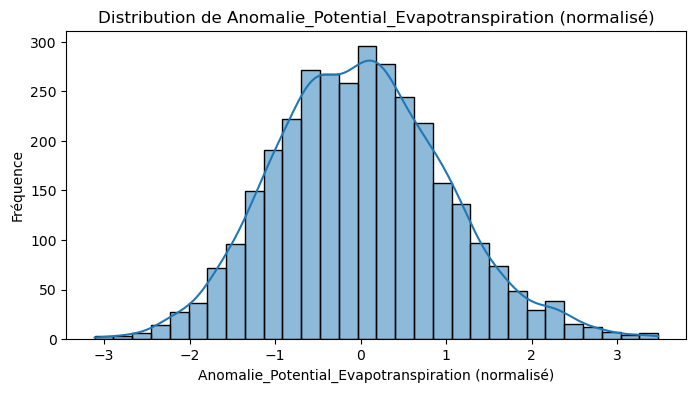

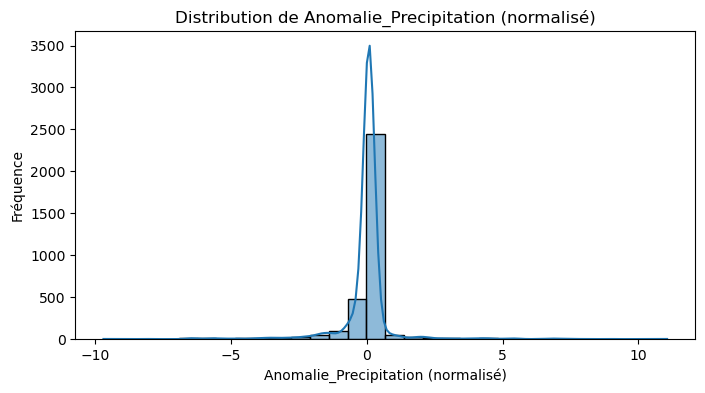

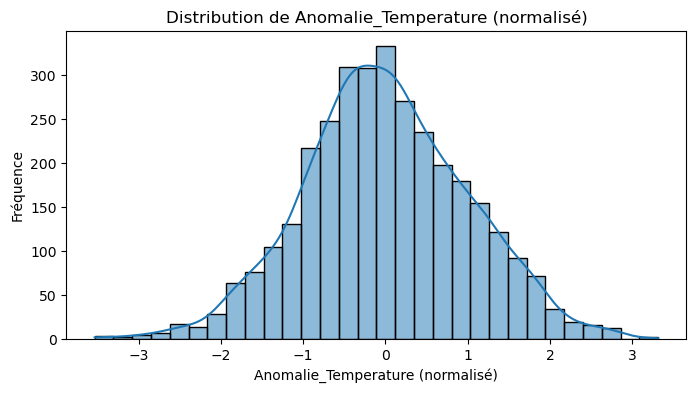

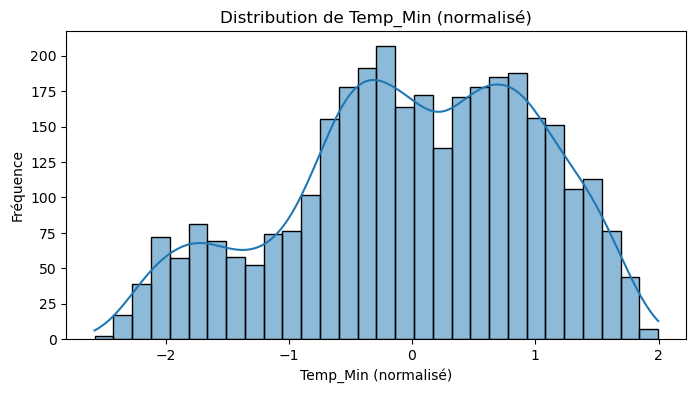

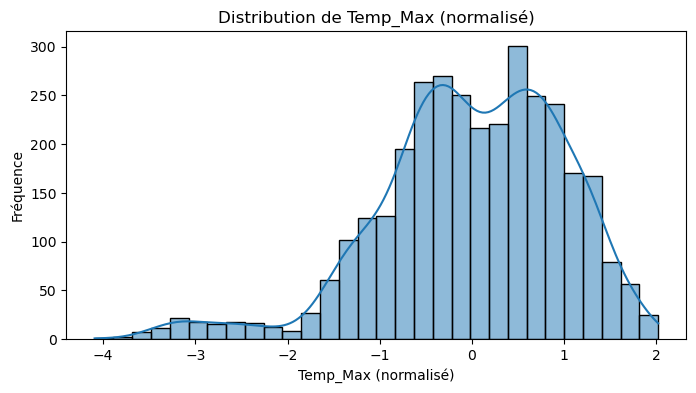

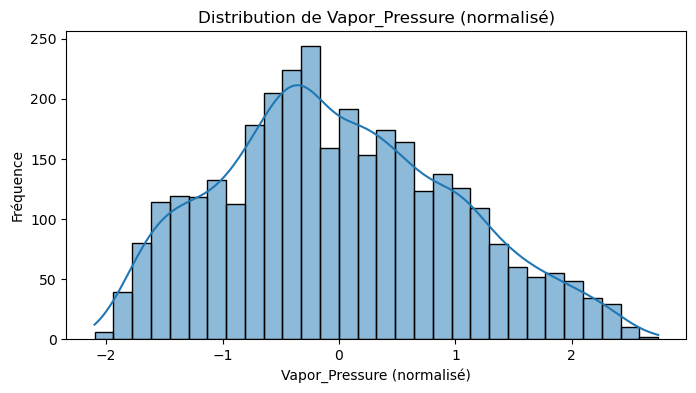

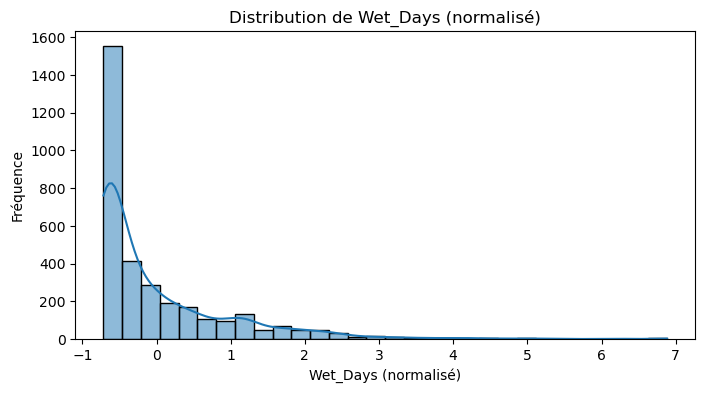

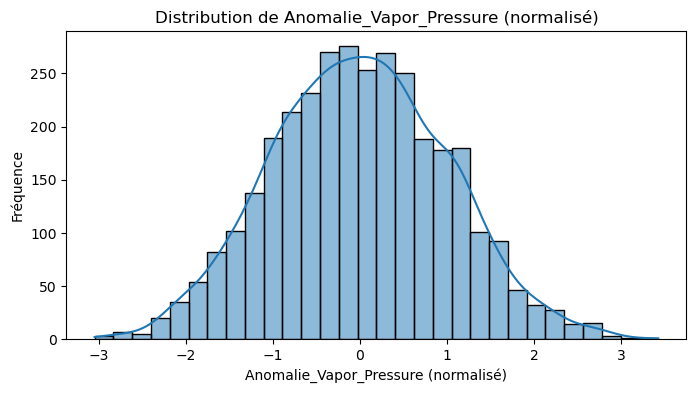

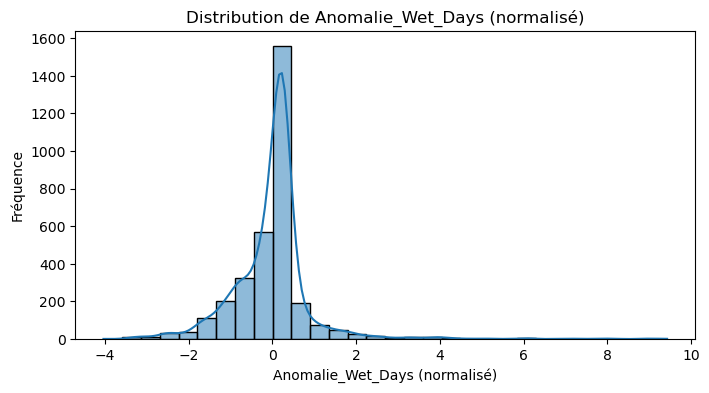

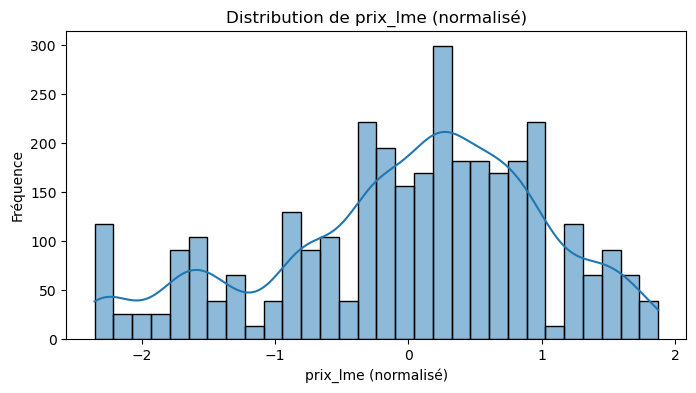

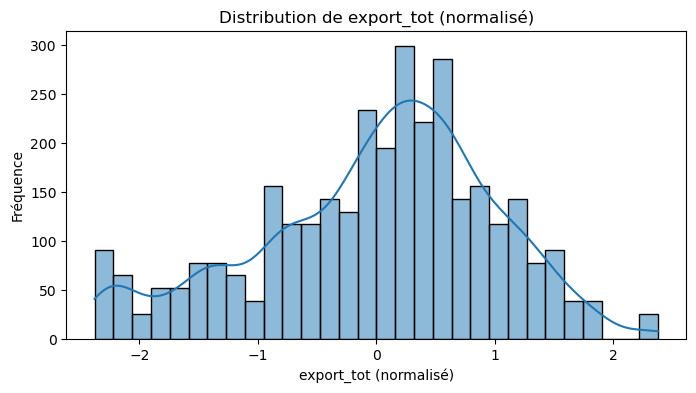

In [8]:
# Visualisation : Histogrammes des variables normalisées
for var in key_vars:
    plt.figure(figsize=(8,4))
    sns.histplot(df_norm[var + "_norm"], kde=True, bins=30)
    plt.title(f"Distribution de {var} (normalisé)")
    plt.xlabel(f"{var} (normalisé)")
    plt.ylabel("Fréquence")
    plt.show()

## 5. Sélection de la période d'étude (Panel)

In [9]:
# Garder uniquement la période de 2003-01 à 2023-12
df_panel = df_norm[(df_norm['Date'] >= '2003-01-01') & (df_norm['Date'] <= '2023-12-31')]
print("\nPériode d'étude (panel) :", df_panel['Date'].min(), "à", df_panel['Date'].max())
print("Nombre de mines :", df_panel['Mine'].nunique())

# Sauvegarder le DataFrame préparé pour la suite des analyses
df_panel.to_csv("final_merged_data_normalized.csv", index=False)



Période d'étude (panel) : 2003-01-01 00:00:00 à 2023-12-01 00:00:00
Nombre de mines : 13


## 6. Statistiques descriptives

In [10]:
desc_stats = df_panel[key_vars].describe()
print("\nStatistiques descriptives :")
print(desc_stats)


Statistiques descriptives :
        Production  Temperature  Precipitation  Cloud_Cover  \
count  3276.000000  3276.000000    3276.000000  3276.000000   
mean     19.872858    10.533883       6.719841    41.661814   
std      24.683506     4.612390      20.160905    11.986864   
min       0.000000    -4.300000       0.000000     6.100000   
25%       6.200000     7.700000       0.200000    33.200001   
50%      10.884000    10.700000       0.700000    40.000000   
75%      20.100000    14.100000       3.500000    49.500000   
max     150.399994    19.900000     269.300018    82.599998   

       Diurnal_Temp_Range    Frost_Days  Potential_Evapotranspiration  \
count         3276.000000  3.276000e+03                   3276.000000   
mean            11.141545  7.016555e+14                      3.314011   
std              2.492271  7.728971e+14                      0.869730   
min              6.300000  0.000000e+00                      0.900000   
25%              9.275000  8.639999e+1

## 7. Corrélation

In [11]:
# Matrice de corrélation
corr_matrix = df_panel[key_vars].corr()
print("\nMatrice de corrélation :")
print(corr_matrix)



Matrice de corrélation :
                                       Production  Temperature  Precipitation  \
Production                               1.000000    -0.045207       0.017786   
Temperature                             -0.045207     1.000000      -0.279585   
Precipitation                            0.017786    -0.279585       1.000000   
Cloud_Cover                             -0.023868     0.182458       0.105593   
Diurnal_Temp_Range                       0.029112    -0.601189      -0.233231   
Frost_Days                               0.015334    -0.938398       0.186522   
Potential_Evapotranspiration            -0.004676     0.629584      -0.301651   
Anomalie_Cloud_Cover                    -0.021334     0.008004      -0.063629   
Anomalie_Diurnal_Temp_Range              0.015019    -0.045990       0.061974   
Anomalie_Frost_Days                     -0.059523    -0.055624      -0.017796   
Anomalie_Potential_Evapotranspiration    0.034270     0.306655      -0.065092   
An

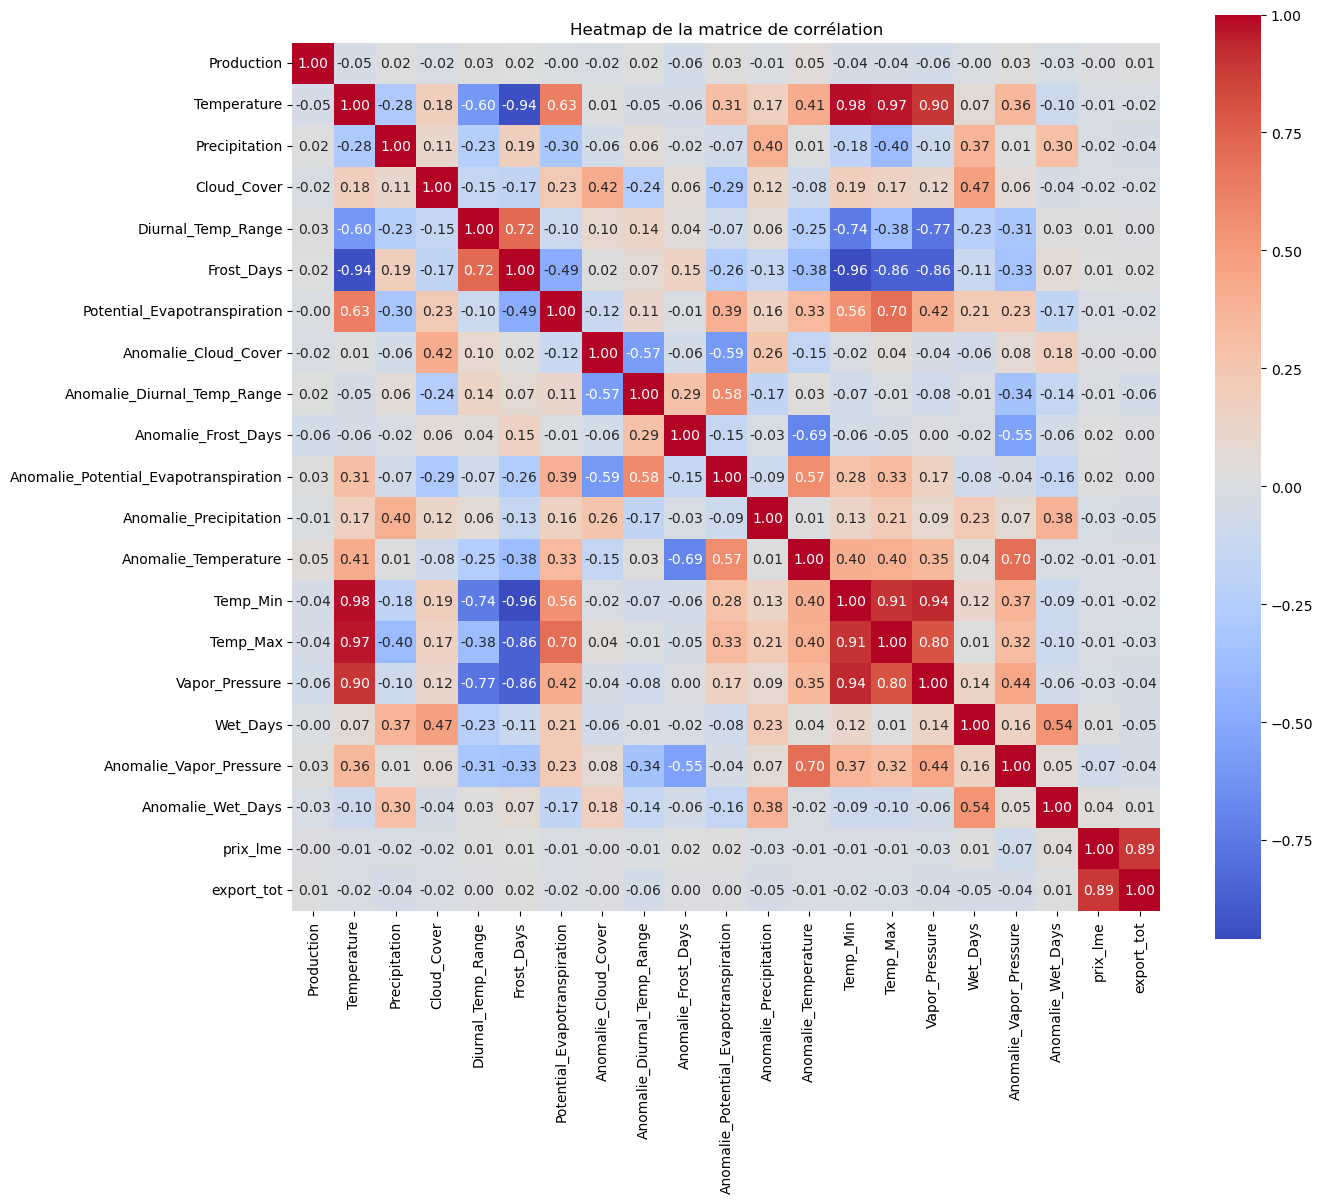

In [12]:
# Visualisation de la matrice de corrélation
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)
plt.title("Heatmap de la matrice de corrélation")
plt.show()